In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import  RandomOverSampler

In [47]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist" , "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [48]:
df["class"] = df["class"].map({"g": 1, "h": 0})
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


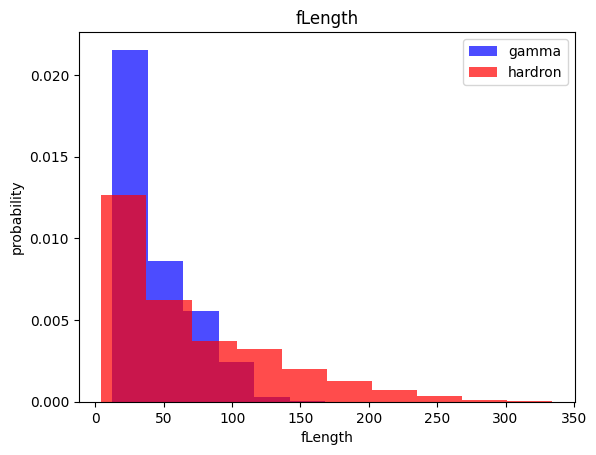

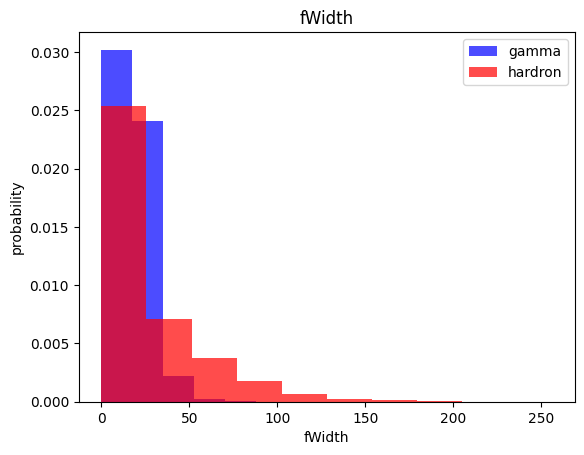

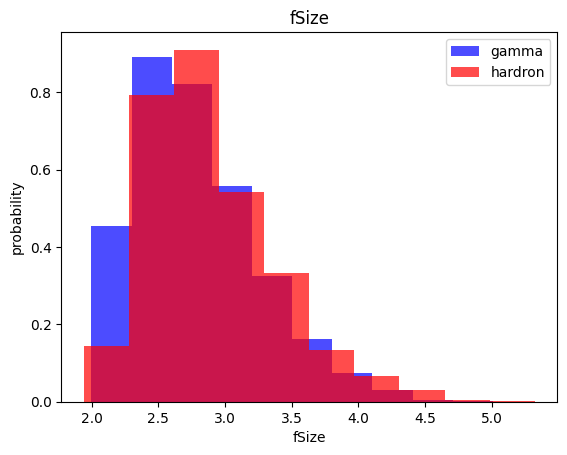

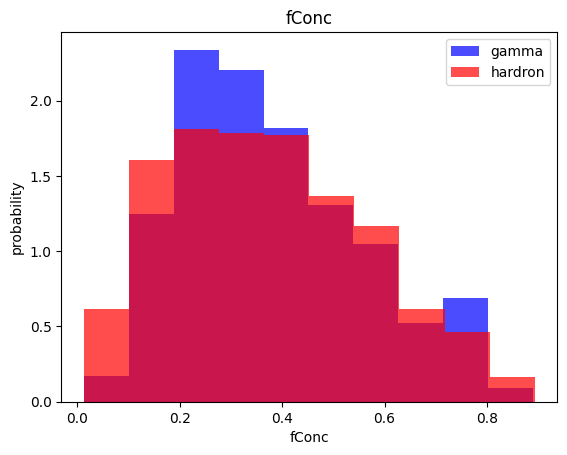

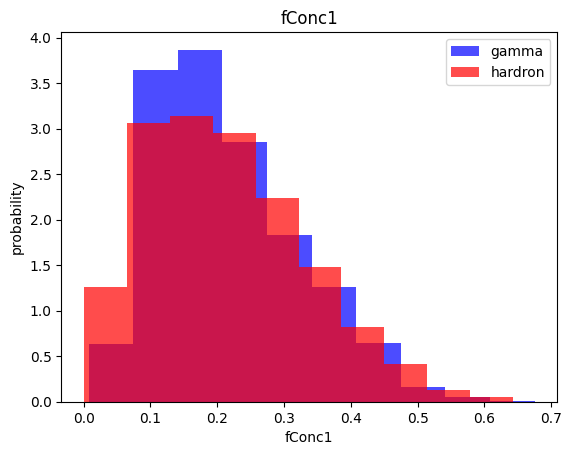

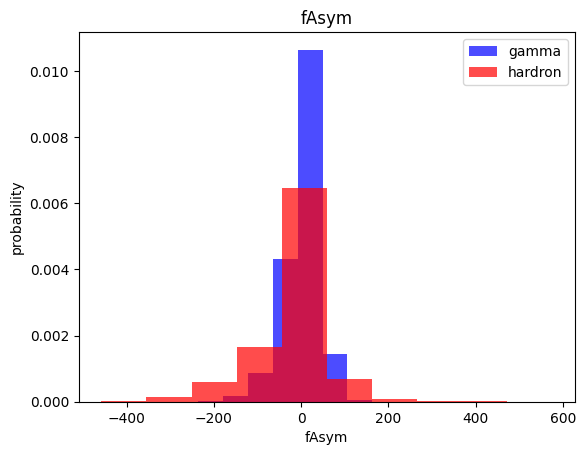

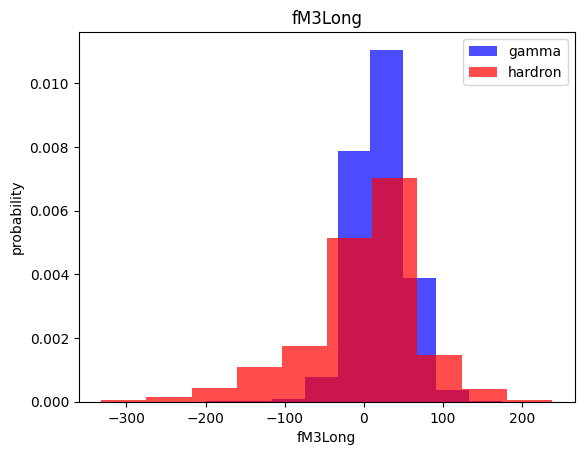

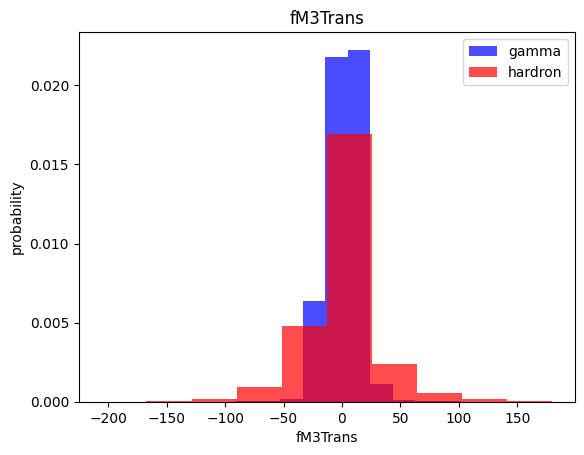

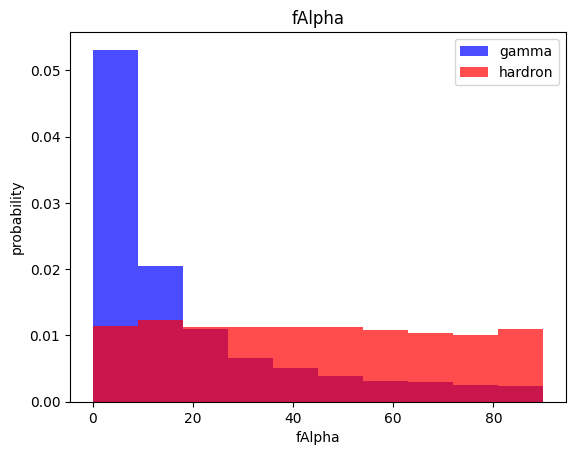

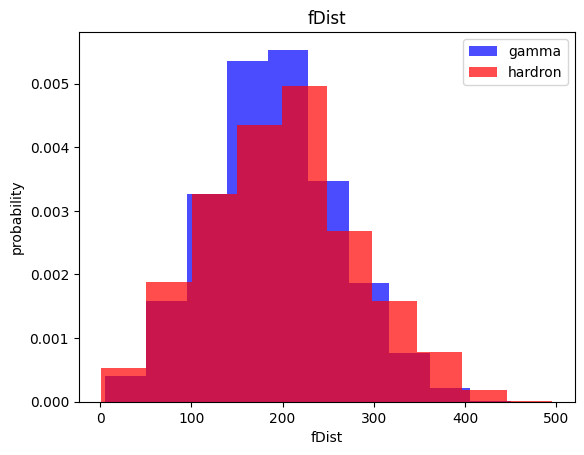

In [49]:
for lable in cols[:-1]:
    plt.hist(df[df["class"]==1][lable], color="blue",  label="gamma" ,alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][lable], color="red",  label="hardron" ,alpha=0.7, density=True)
    plt.title(lable)
    plt.xlabel(lable)
    plt.ylabel("probability")
    plt.legend()
    plt.show()

In [50]:
train , valid , test = np.split(df.sample(frac = 1), [int(.6*len(df)), int(.8*len(df))])

In [51]:


def scale_dataframe(dataframe, oversample=False):

    x = dataframe[:, :-1]   # all columns except last
    y = dataframe[:, -1]    # last column

    scaler = StandardScaler()
    x = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler()
        x, y = ros.fit_resample(x, y)

    data = np.hstack((x, y.reshape(-1,1)))

    return data, x, y

In [52]:
train, x_train, y_train = scale_dataframe(train, oversample=True)
valid, x_valid, y_valid = scale_dataframe(valid, oversample=False)
test, x_test, y_test = scale_dataframe(test, oversample=False)
